# VinDr Mammogram Dataset EDA

This notebook describes my exploratory data analysis of the VinDr Mammogram dataset.

The official VinDr-Mammo dataset is hosted on PhysioNet, but I was unable to obtain access
to download it directly. Instead, I am using a pre-processed version available on Kaggle:
https://www.kaggle.com/datasets/shantanughosh/vindr-mammogram-dataset-dicom-to-png

This Kaggle dataset was created as part of the MICCAI 2024 paper "Mammo-CLIP" and contains
PNG images converted from the original DICOM files. All images have been resized to
**1520×912 pixels**, which differs from the original full-resolution mammograms.

## Imports

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
from matplotlib.patches import Rectangle

## Dataset Overview

The VinDr mammogram dataset contains:
- PNG images resized to 1520×912 pixels
- Metadata including BI-RADS assessments, breast density, and finding annotations
- Bounding box coordinates for detected findings

In [2]:
VINDR_ROOT = Path("../datasets/vindr-mammogram-dataset-dicom-to-png")
IMAGES_DIR = VINDR_ROOT / "images_png"

In [3]:
# Load the metadata CSV
vindr_df = pd.read_csv(VINDR_ROOT / "vindr_detection_v1_folds.csv")

/var/folders/m9/jlntzhk17ms42d1rwzzkrmzm0000gn/T/ipykernel_27555/2595576230.py:2: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  vindr_df = pd.read_csv(VINDR_ROOT / "vindr_detection_v1_folds.csv")


## Metadata File Review

In [4]:
print(f"Total number of rows: {len(vindr_df)}")
print(f"Number of unique patients: {vindr_df['patient_id'].nunique()}")
print(f"Number of unique images: {vindr_df['image_id'].nunique()}")
print(f"\nDataset shape: {vindr_df.shape}")

Total number of rows: 20486
Number of unique patients: 5000
Number of unique images: 20000

Dataset shape: (20486, 33)


In [5]:
# Check the columns
print("Columns:")
for col in vindr_df.columns:
    print(f"  - {col}")

Columns:
  - patient_id
  - series_id
  - image_id
  - laterality
  - view
  - height
  - width
  - breast_birads
  - breast_density
  - finding_categories
  - finding_birads
  - xmin
  - ymin
  - xmax
  - ymax
  - split
  - resized_xmin
  - resized_ymin
  - resized_xmax
  - resized_ymax
  - fold
  - Architectural_Distortion
  - Asymmetry
  - Focal_Asymmetry
  - Global_Asymmetry
  - Mass
  - Nipple_Retraction
  - No_Finding
  - Skin_Retraction
  - Skin_Thickening
  - Suspicious_Calcification
  - Suspicious_Lymph_Node
  - density


In [6]:
vindr_df.head()

,patient_id,series_id,image_id,laterality,view,height,width,breast_birads,breast_density,finding_categories,...,Focal_Asymmetry,Global_Asymmetry,Mass,Nipple_Retraction,No_Finding,Skin_Retraction,Skin_Thickening,Suspicious_Calcification,Suspicious_Lymph_Node,density
0,48575a27b7c992427041a82fa750d3fa,26de4993fa6b8ae50a91c8baf49b92b0,4e3a578fe535ea4f5258d3f7f4419db8.png,R,CC,3518,2800,BI-RADS 4,DENSITY C,['Mass'],...,0,0,1,0,0,0,0,0,0,2
1,48575a27b7c992427041a82fa750d3fa,26de4993fa6b8ae50a91c8baf49b92b0,dac39351b0f3a8c670b7f8dc88029364.png,R,MLO,3518,2800,BI-RADS 4,DENSITY C,['Mass'],...,0,0,1,0,0,0,0,0,0,2
2,75e8e48933289d70b407379a564f8594,853b70e7e6f39133497909d9ca4c756d,c83f780904f25eacb44e9030f32c66e1.png,R,CC,3518,2800,BI-RADS 3,DENSITY C,['Global Asymmetry'],...,0,1,0,0,0,0,0,0,0,2
3,75e8e48933289d70b407379a564f8594,853b70e7e6f39133497909d9ca4c756d,893528bc38a0362928a89364f1b692fd.png,R,MLO,3518,2800,BI-RADS 3,DENSITY C,['Global Asymmetry'],...,0,1,0,0,0,0,0,0,0,2
4,c3487424fee1bdd4515b72dc3fd69813,77619c914263eae44e9099f1ce07192c,318264c881bf12f2c1efe5f93920cc37.png,R,CC,3518,2800,BI-RADS 4,DENSITY C,['Architectural Distortion'],...,0,0,0,0,0,0,0,0,0,2


## Understanding the Data Structure

Each row represents a finding annotation on an image. An image may have multiple rows
if it contains multiple findings. Images with "No Finding" have a single row.

In [7]:
# Check for images with multiple findings
findings_per_image = vindr_df.groupby('image_id').size()
print(f"Images with single annotation: {(findings_per_image == 1).sum()}")
print(f"Images with multiple annotations: {(findings_per_image > 1).sum()}")
print(f"\nMax annotations per image: {findings_per_image.max()}")

Images with single annotation: 19662
Images with multiple annotations: 338

Max annotations per image: 7


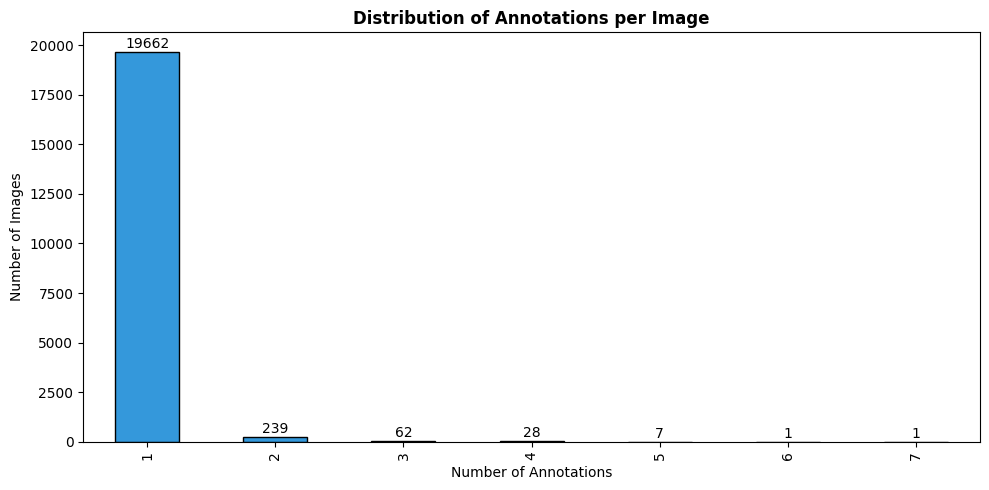

In [8]:
# Distribution of annotations per image
fig, ax = plt.subplots(figsize=(10, 5))
findings_per_image.value_counts().sort_index().plot(kind='bar', ax=ax, color='#3498db', edgecolor='black')
ax.set_title('Distribution of Annotations per Image', fontsize=12, fontweight='bold')
ax.set_xlabel('Number of Annotations')
ax.set_ylabel('Number of Images')
for i, v in enumerate(findings_per_image.value_counts().sort_index().values):
    ax.text(i, v + 50, str(v), ha='center', va='bottom')
plt.tight_layout()
plt.show()

## Train/Test Split Distribution

In [9]:
split_counts = vindr_df.groupby('split')['patient_id'].nunique()
print("Patients per split:")
print(split_counts)

Patients per split:
split
test        1000
training    4000
Name: patient_id, dtype: int64


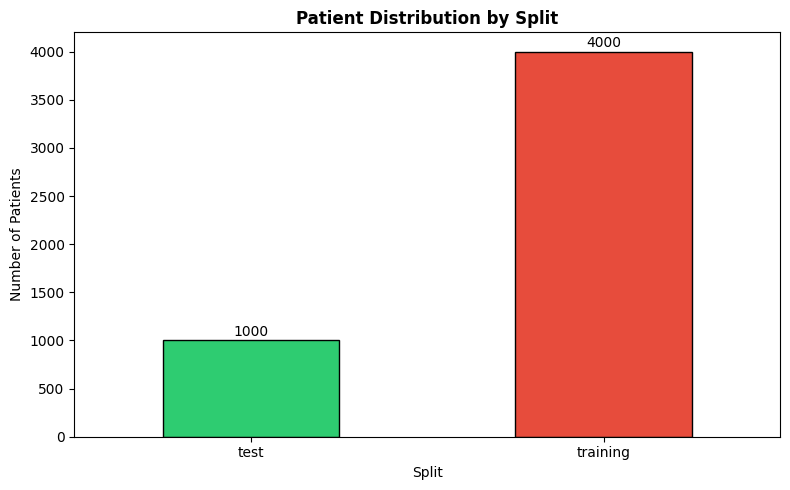

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))
split_counts.plot(kind='bar', ax=ax, color=['#2ecc71', '#e74c3c'], edgecolor='black')
ax.set_title('Patient Distribution by Split', fontsize=12, fontweight='bold')
ax.set_xlabel('Split')
ax.set_ylabel('Number of Patients')
ax.tick_params(axis='x', rotation=0)
for i, v in enumerate(split_counts.values):
    ax.text(i, v + 20, str(v), ha='center', va='bottom')
plt.tight_layout()
plt.show()

## BI-RADS Assessment Distribution

The breast-level BI-RADS (Breast Imaging Reporting and Data System) assessment:
- BI-RADS 1: Negative
- BI-RADS 2: Benign
- BI-RADS 3: Probably benign
- BI-RADS 4: Suspicious
- BI-RADS 5: Highly suggestive of malignancy

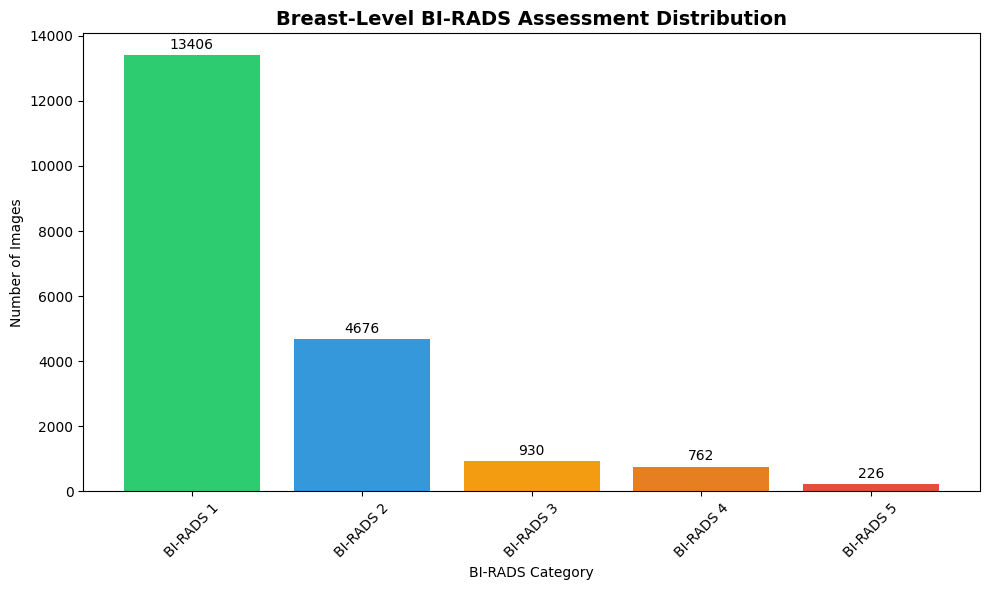

In [11]:
# Get unique images with their BI-RADS to avoid counting duplicates
image_birads = vindr_df.drop_duplicates(subset=['image_id'])[['image_id', 'breast_birads']]

fig, ax = plt.subplots(figsize=(10, 6))
birads_counts = image_birads['breast_birads'].value_counts().sort_index()
colors = ['#2ecc71', '#3498db', '#f39c12', '#e67e22', '#e74c3c']
ax.bar(birads_counts.index, birads_counts.values, color=colors[:len(birads_counts)])
ax.set_title('Breast-Level BI-RADS Assessment Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('BI-RADS Category')
ax.set_ylabel('Number of Images')
ax.tick_params(axis='x', rotation=45)
for i, v in enumerate(birads_counts.values):
    ax.text(i, v + 100, str(v), ha='center', va='bottom')
plt.tight_layout()
plt.show()

### Creating Binary Labels

For classification, we create binary labels:
- Benign/Normal: BI-RADS 1, 2, 3
- Suspicious/Malignant: BI-RADS 4, 5

In [12]:
def classify_birads(birads_str):
    if birads_str in ['BI-RADS 1', 'BI-RADS 2', 'BI-RADS 3']:
        return 'Benign/Normal'
    elif birads_str in ['BI-RADS 4', 'BI-RADS 5']:
        return 'Suspicious/Malignant'
    else:
        return 'Unknown'

image_birads['pathology'] = image_birads['breast_birads'].apply(classify_birads)

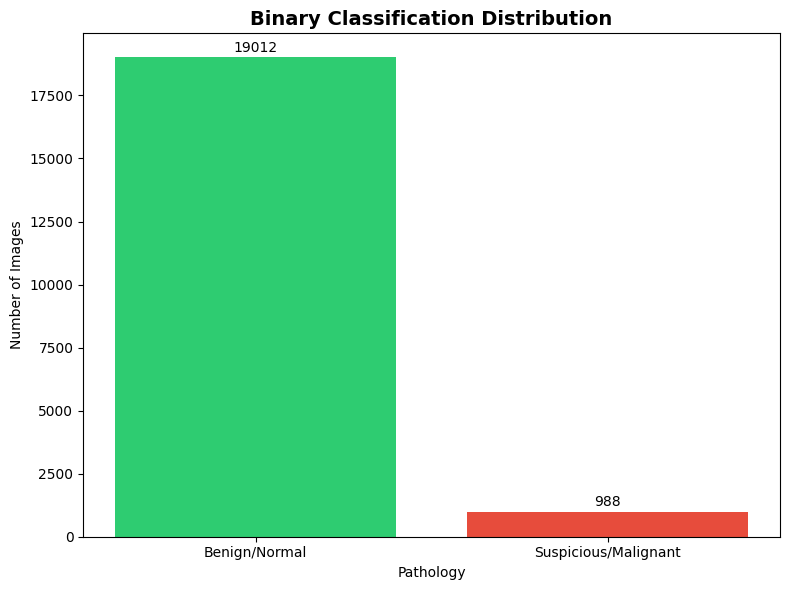

In [13]:
fig, ax = plt.subplots(figsize=(8, 6))
pathology_counts = image_birads['pathology'].value_counts()
colors_pathology = ['#2ecc71', '#e74c3c', '#95a5a6']
ax.bar(pathology_counts.index, pathology_counts.values, color=colors_pathology[:len(pathology_counts)])
ax.set_title('Binary Classification Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Pathology')
ax.set_ylabel('Number of Images')
for i, v in enumerate(pathology_counts.values):
    ax.text(i, v + 100, str(v), ha='center', va='bottom')
plt.tight_layout()
plt.show()

## Breast Density Distribution

ACR breast density classification:
- DENSITY A: Almost entirely fatty
- DENSITY B: Scattered fibroglandular densities
- DENSITY C: Heterogeneously dense
- DENSITY D: Extremely dense

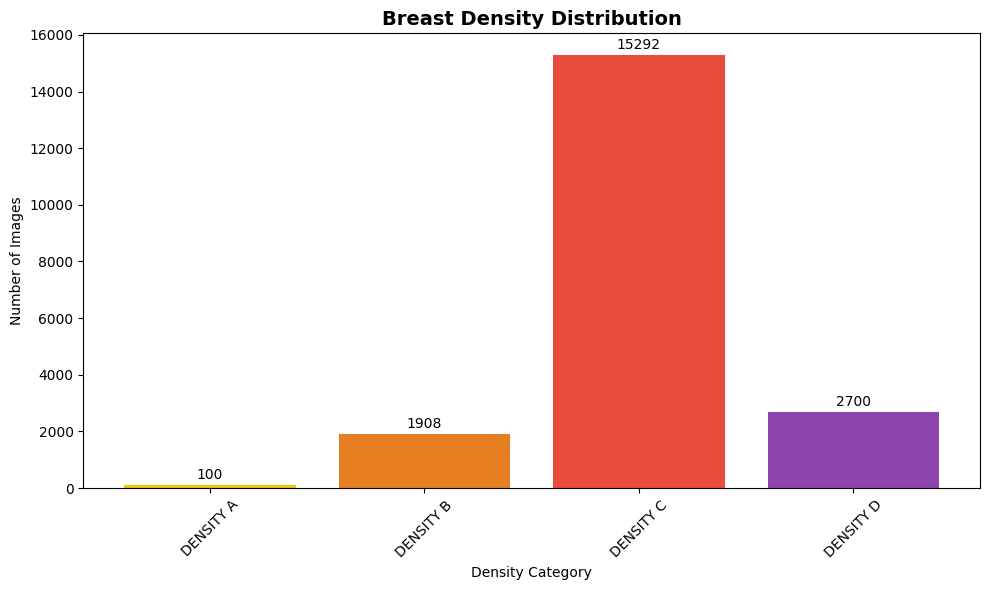

In [14]:
image_density = vindr_df.drop_duplicates(subset=['image_id'])[['image_id', 'breast_density']]

fig, ax = plt.subplots(figsize=(10, 6))
density_counts = image_density['breast_density'].value_counts().sort_index()
colors_density = ['#f1c40f', '#e67e22', '#e74c3c', '#8e44ad']
ax.bar(density_counts.index, density_counts.values, color=colors_density[:len(density_counts)])
ax.set_title('Breast Density Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Density Category')
ax.set_ylabel('Number of Images')
ax.tick_params(axis='x', rotation=45)
for i, v in enumerate(density_counts.values):
    ax.text(i, v + 100, str(v), ha='center', va='bottom')
plt.tight_layout()
plt.show()

## View and Laterality Distribution

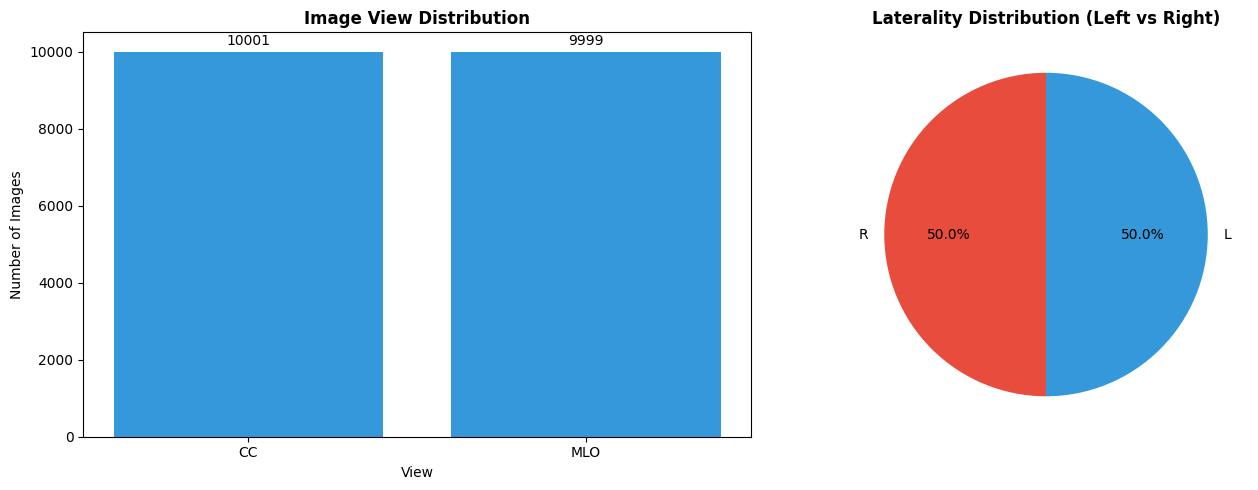

In [15]:
image_meta = vindr_df.drop_duplicates(subset=['image_id'])[['image_id', 'laterality', 'view']]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# View distribution
view_counts = image_meta['view'].value_counts()
axes[0].bar(view_counts.index, view_counts.values, color='#3498db')
axes[0].set_title('Image View Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('View')
axes[0].set_ylabel('Number of Images')
for i, v in enumerate(view_counts.values):
    axes[0].text(i, v + 100, str(v), ha='center', va='bottom')

# Laterality distribution
laterality_counts = image_meta['laterality'].value_counts()
axes[1].pie(laterality_counts.values, labels=laterality_counts.index, autopct='%1.1f%%',
            colors=['#e74c3c', '#3498db'], startangle=90)
axes[1].set_title('Laterality Distribution (Left vs Right)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## Finding Categories Distribution

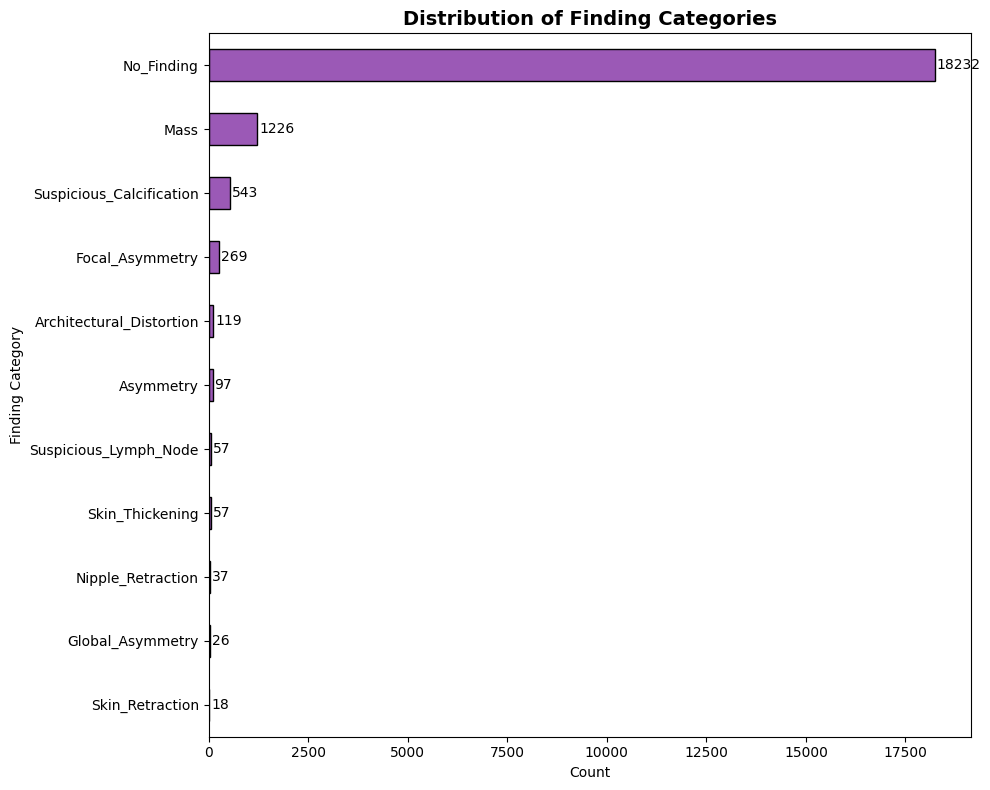

In [16]:
# Count findings across all annotations
finding_columns = [
    'Architectural_Distortion', 'Asymmetry', 'Focal_Asymmetry', 'Global_Asymmetry',
    'Mass', 'Nipple_Retraction', 'No_Finding', 'Skin_Retraction',
    'Skin_Thickening', 'Suspicious_Calcification', 'Suspicious_Lymph_Node'
]

finding_counts = vindr_df[finding_columns].sum().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
finding_counts.plot(kind='barh', ax=ax, color='#9b59b6', edgecolor='black')
ax.set_title('Distribution of Finding Categories', fontsize=14, fontweight='bold')
ax.set_xlabel('Count')
ax.set_ylabel('Finding Category')
for i, v in enumerate(finding_counts.values):
    ax.text(v + 50, i, str(int(v)), va='center')
plt.tight_layout()
plt.show()

## Cross-Analysis: BI-RADS by Density

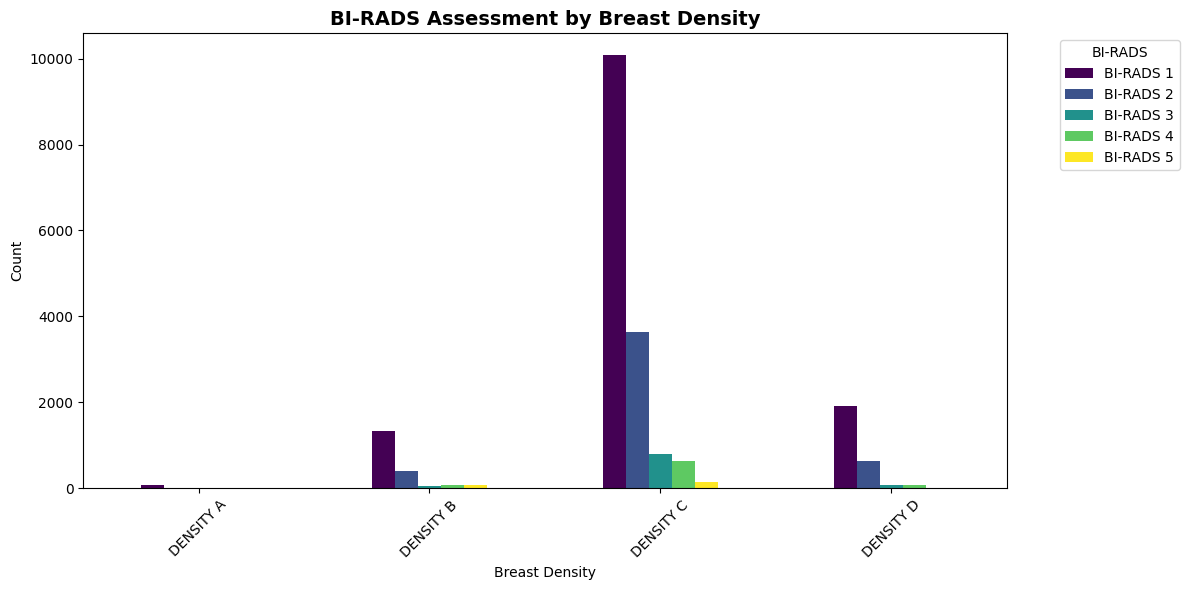

In [17]:
image_cross = vindr_df.drop_duplicates(subset=['image_id'])[['image_id', 'breast_birads', 'breast_density']]

fig, ax = plt.subplots(figsize=(12, 6))
birads_density = pd.crosstab(image_cross['breast_density'], image_cross['breast_birads'])
birads_density.plot(kind='bar', ax=ax, colormap='viridis')
ax.set_title('BI-RADS Assessment by Breast Density', fontsize=14, fontweight='bold')
ax.set_xlabel('Breast Density')
ax.set_ylabel('Count')
ax.legend(title='BI-RADS', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## Fold Distribution (Cross-Validation)

Patients per fold:
fold
0    1250
1    1250
2    1250
3    1250
Name: patient_id, dtype: int64


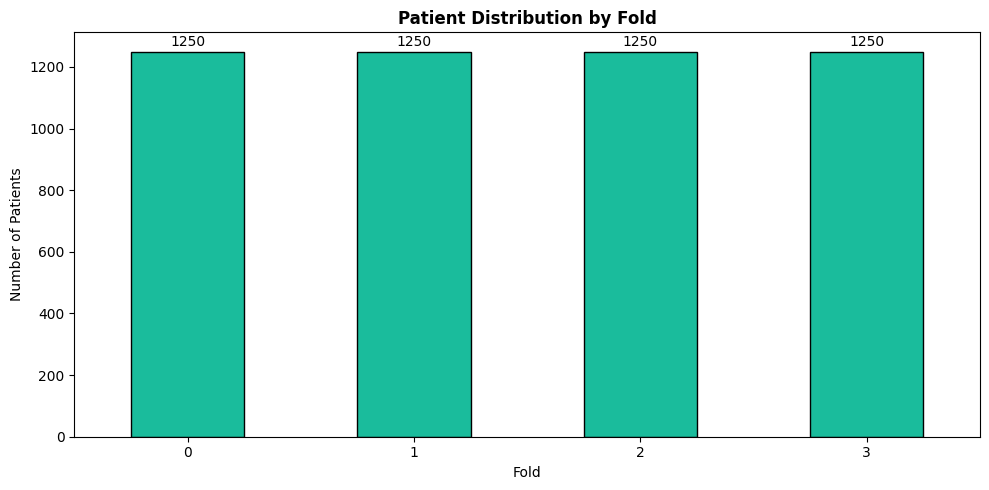

In [18]:
fold_counts = vindr_df.groupby('fold')['patient_id'].nunique()
print("Patients per fold:")
print(fold_counts)

fig, ax = plt.subplots(figsize=(10, 5))
fold_counts.plot(kind='bar', ax=ax, color='#1abc9c', edgecolor='black')
ax.set_title('Patient Distribution by Fold', fontsize=12, fontweight='bold')
ax.set_xlabel('Fold')
ax.set_ylabel('Number of Patients')
ax.tick_params(axis='x', rotation=0)
for i, v in enumerate(fold_counts.values):
    ax.text(i, v + 10, str(v), ha='center', va='bottom')
plt.tight_layout()
plt.show()

## Image Visualisation

Let's look at some sample images from the dataset.

In [19]:
def load_vindr_image(patient_id, image_id):
    """Load a VinDr PNG image."""
    img_path = IMAGES_DIR / patient_id / image_id
    if not img_path.exists():
        # Try with .png extension if not already included
        if not image_id.endswith('.png'):
            img_path = IMAGES_DIR / patient_id / f"{image_id}.png"
    return Image.open(img_path)


def get_image_path(row):
    """Get full path to an image from a dataframe row."""
    return IMAGES_DIR / row['patient_id'] / row['image_id']

In [20]:
# Get a sample image with findings
sample_with_finding = vindr_df[vindr_df['No_Finding'] == 0].iloc[0]
print(f"Sample image with findings:")
print(f"  Patient ID: {sample_with_finding['patient_id']}")
print(f"  Image ID: {sample_with_finding['image_id']}")
print(f"  BI-RADS: {sample_with_finding['breast_birads']}")
print(f"  Finding: {sample_with_finding['finding_categories']}")

Sample image with findings:
  Patient ID: 48575a27b7c992427041a82fa750d3fa
  Image ID: 4e3a578fe535ea4f5258d3f7f4419db8.png
  BI-RADS: BI-RADS 4
  Finding: ['Mass']


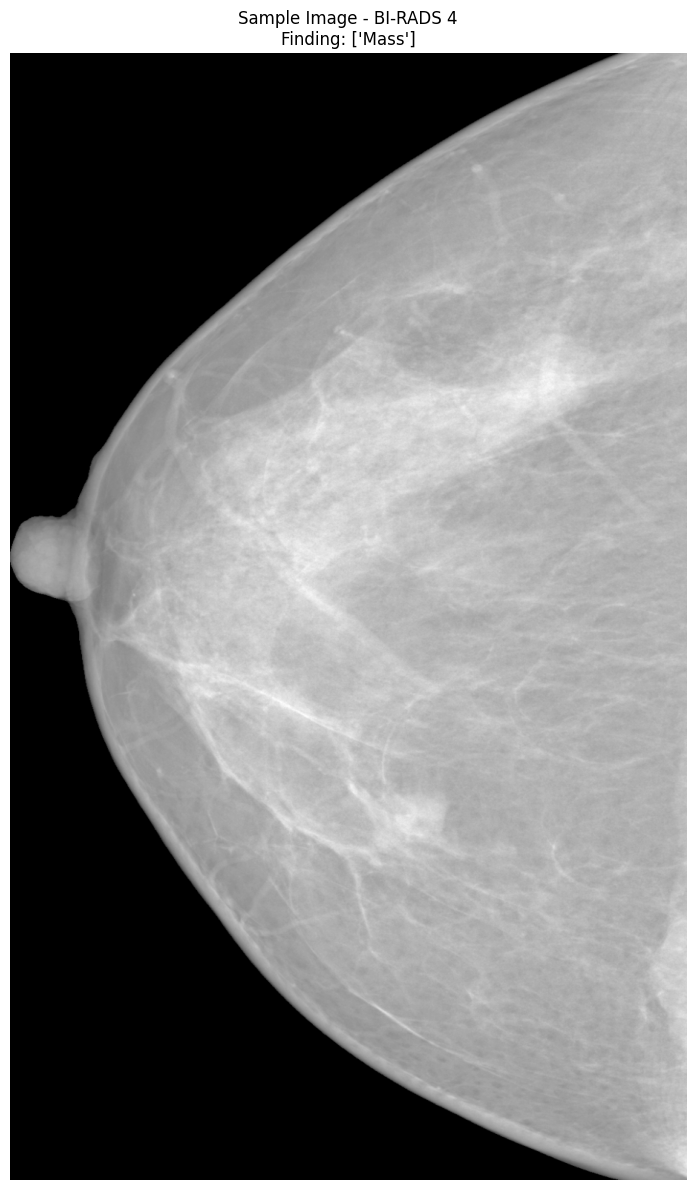

Image shape: (1520, 912)
Pixel value range: [0, 207]


In [21]:
# Load and display the sample image
sample_img = load_vindr_image(sample_with_finding['patient_id'], sample_with_finding['image_id'])
sample_img_array = np.array(sample_img)

fig, ax = plt.subplots(figsize=(8, 12))
ax.imshow(sample_img_array, cmap='gray')
ax.set_title(f"Sample Image - {sample_with_finding['breast_birads']}\nFinding: {sample_with_finding['finding_categories']}")
ax.axis('off')
plt.tight_layout()
plt.show()

print(f"Image shape: {sample_img_array.shape}")
print(f"Pixel value range: [{sample_img_array.min()}, {sample_img_array.max()}]")

### Visualising Bounding Boxes

The dataset includes resized bounding box coordinates for findings.

In [22]:
# Get all annotations for a single image with multiple findings
multi_finding_images = vindr_df.groupby('image_id').filter(lambda x: len(x) > 1)
if len(multi_finding_images) > 0:
    sample_image_id = multi_finding_images['image_id'].iloc[0]
    sample_annotations = vindr_df[vindr_df['image_id'] == sample_image_id]

    print(f"Image with {len(sample_annotations)} findings:")
    print(sample_annotations[['finding_categories', 'finding_birads', 'resized_xmin', 'resized_ymin', 'resized_xmax', 'resized_ymax']])

Image with 2 findings:
              finding_categories finding_birads  resized_xmin  resized_ymin  \
14  ['Architectural Distortion']      BI-RADS 5     398.30903    744.640990   
15                      ['Mass']      BI-RADS 4       0.00000    916.904813   

    resized_xmax  resized_ymax  
14    593.291825    968.824221  
15    174.744578   1077.182779  


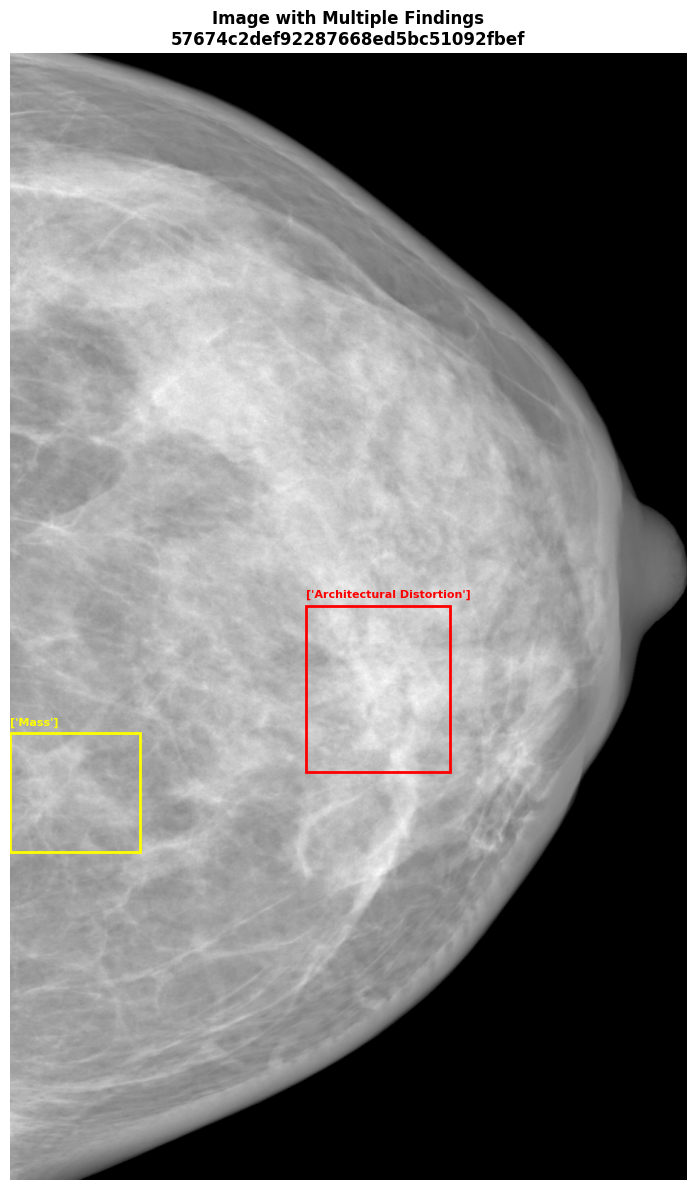

In [23]:
# Display image with bounding boxes
if len(multi_finding_images) > 0:
    patient_id = sample_annotations['patient_id'].iloc[0]
    img = load_vindr_image(patient_id, sample_image_id)
    img_array = np.array(img)

    fig, ax = plt.subplots(figsize=(8, 12))
    ax.imshow(img_array, cmap='gray')

    colors = ['red', 'yellow', 'cyan', 'magenta', 'orange']
    for idx, (_, row) in enumerate(sample_annotations.iterrows()):
        if pd.notna(row['resized_xmin']):
            x = row['resized_xmin']
            y = row['resized_ymin']
            w = row['resized_xmax'] - row['resized_xmin']
            h = row['resized_ymax'] - row['resized_ymin']

            rect = Rectangle((x, y), w, h, linewidth=2,
                            edgecolor=colors[idx % len(colors)], facecolor='none')
            ax.add_patch(rect)
            ax.text(x, y - 10, f"{row['finding_categories']}",
                   color=colors[idx % len(colors)], fontsize=8, fontweight='bold')

    ax.set_title(f"Image with Multiple Findings\n{patient_id}", fontsize=12, fontweight='bold')
    ax.axis('off')
    plt.tight_layout()
    plt.show()

### Comparing Views (CC vs MLO)

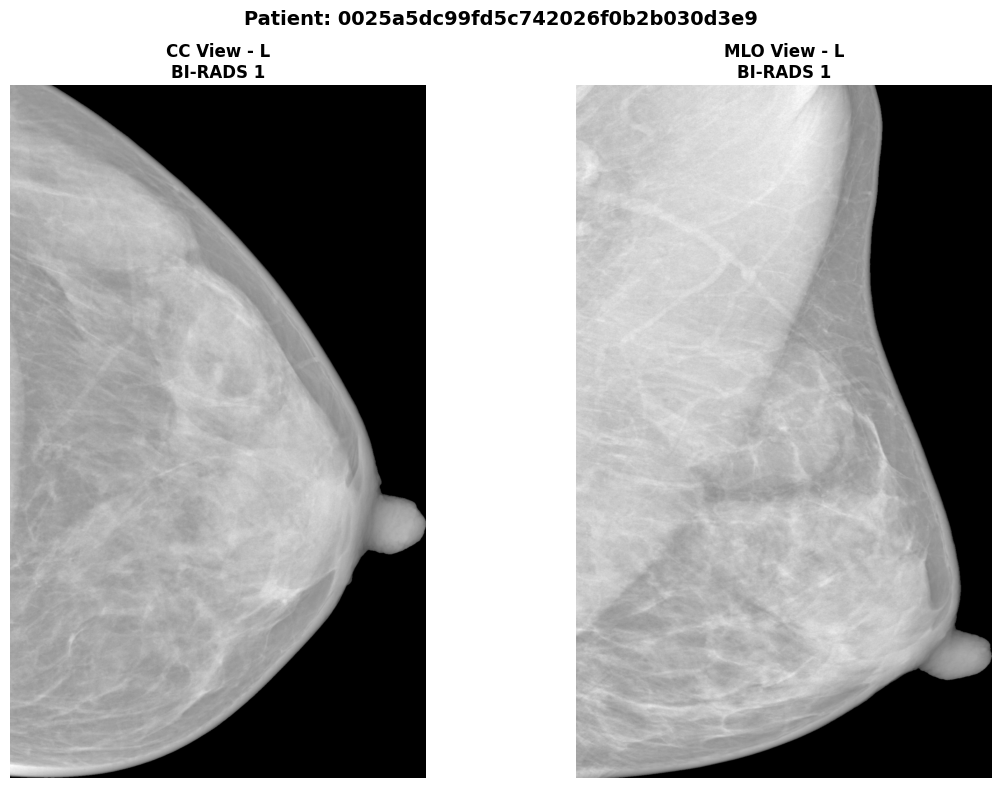

In [24]:
# Find a patient with both CC and MLO views
patient_views = vindr_df.groupby(['patient_id', 'laterality'])['view'].nunique()
patients_with_both = patient_views[patient_views == 2].reset_index()['patient_id'].unique()

if len(patients_with_both) > 0:
    sample_patient = patients_with_both[0]
    patient_data = vindr_df[vindr_df['patient_id'] == sample_patient].drop_duplicates(subset=['image_id'])

    # Get one laterality with both views
    for lat in ['L', 'R']:
        lat_data = patient_data[patient_data['laterality'] == lat]
        if len(lat_data['view'].unique()) == 2:
            cc_row = lat_data[lat_data['view'] == 'CC'].iloc[0]
            mlo_row = lat_data[lat_data['view'] == 'MLO'].iloc[0]

            fig, axes = plt.subplots(1, 2, figsize=(12, 8))

            cc_img = load_vindr_image(cc_row['patient_id'], cc_row['image_id'])
            mlo_img = load_vindr_image(mlo_row['patient_id'], mlo_row['image_id'])

            axes[0].imshow(np.array(cc_img), cmap='gray')
            axes[0].set_title(f'CC View - {lat}\n{cc_row["breast_birads"]}', fontweight='bold')
            axes[0].axis('off')

            axes[1].imshow(np.array(mlo_img), cmap='gray')
            axes[1].set_title(f'MLO View - {lat}\n{mlo_row["breast_birads"]}', fontweight='bold')
            axes[1].axis('off')

            plt.suptitle(f'Patient: {sample_patient}', fontsize=14, fontweight='bold')
            plt.tight_layout()
            plt.show()
            break

## Image Dimensions Analysis

The images are pre-resized to 1520×912, but let's verify this.

In [25]:
# Sample a subset of images to check dimensions (avoid loading all images)
from tqdm import tqdm

def sample_image_dimensions(df, n_samples=100):
    """Sample image dimensions from the dataset."""
    sampled = df.drop_duplicates(subset=['image_id']).sample(n=min(n_samples, len(df)), random_state=42)
    dimensions = []

    for _, row in tqdm(sampled.iterrows(), total=len(sampled), desc="Sampling image dimensions"):
        try:
            img_path = get_image_path(row)
            if img_path.exists():
                img = Image.open(img_path)
                width, height = img.size
                dimensions.append({
                    "patient_id": row['patient_id'],
                    "image_id": row['image_id'],
                    "view": row['view'],
                    "width": width,
                    "height": height,
                    "aspect_ratio": width / height
                })
        except Exception as e:
            print(f"Error processing {row['image_id']}: {e}")

    return pd.DataFrame(dimensions)

In [26]:
dimensions_df = sample_image_dimensions(vindr_df, n_samples=200)

Sampling image dimensions: 100%|██████████████████████████████████████████████████████████████████████| 200/200 [00:00<00:00, 634.07it/s]


In [27]:
print(f"Sampled {len(dimensions_df)} images")
print(f"\nWidth stats: min={dimensions_df['width'].min()}, max={dimensions_df['width'].max()}, "
      f"mean={dimensions_df['width'].mean():.0f}")
print(f"Height stats: min={dimensions_df['height'].min()}, max={dimensions_df['height'].max()}, "
      f"mean={dimensions_df['height'].mean():.0f}")

Sampled 200 images

Width stats: min=912, max=912, mean=912
Height stats: min=1520, max=1520, mean=1520


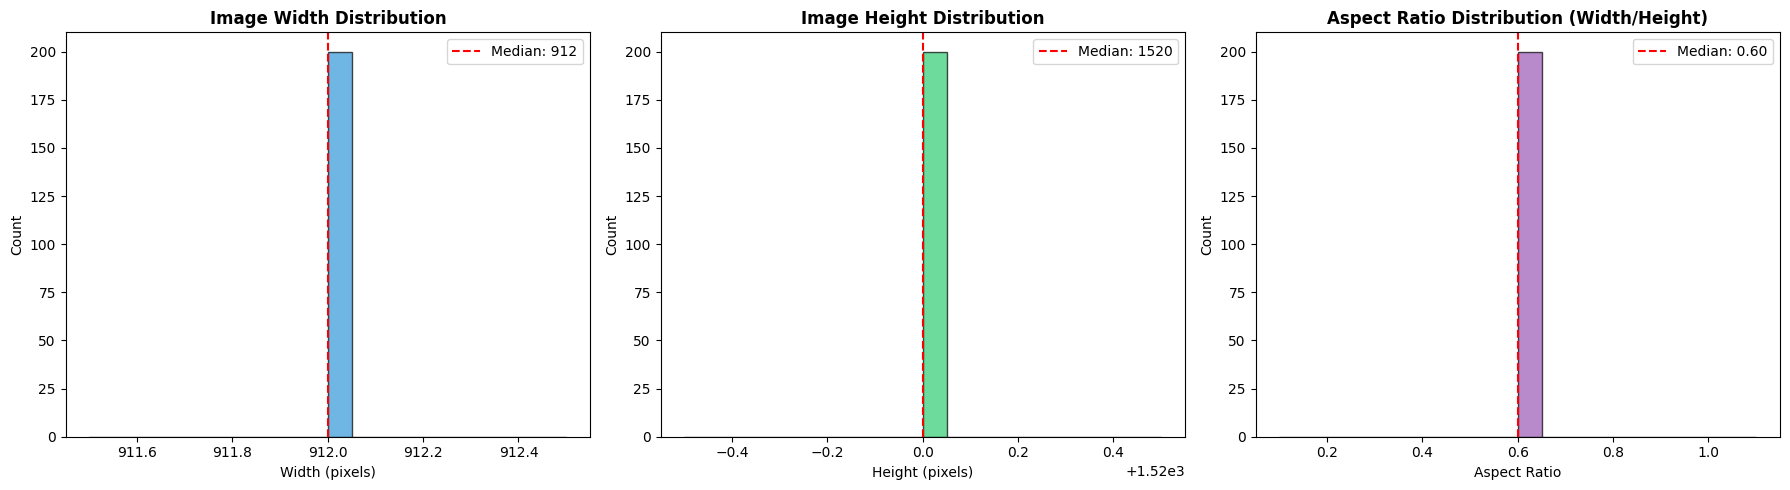

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Width distribution
axes[0].hist(dimensions_df['width'], bins=20, color='#3498db', edgecolor='black', alpha=0.7)
axes[0].set_title('Image Width Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Width (pixels)')
axes[0].set_ylabel('Count')
axes[0].axvline(dimensions_df['width'].median(), color='red', linestyle='--',
                label=f"Median: {dimensions_df['width'].median():.0f}")
axes[0].legend()

# Height distribution
axes[1].hist(dimensions_df['height'], bins=20, color='#2ecc71', edgecolor='black', alpha=0.7)
axes[1].set_title('Image Height Distribution', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Height (pixels)')
axes[1].set_ylabel('Count')
axes[1].axvline(dimensions_df['height'].median(), color='red', linestyle='--',
                label=f"Median: {dimensions_df['height'].median():.0f}")
axes[1].legend()

# Aspect ratio distribution
axes[2].hist(dimensions_df['aspect_ratio'], bins=20, color='#9b59b6', edgecolor='black', alpha=0.7)
axes[2].set_title('Aspect Ratio Distribution (Width/Height)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Aspect Ratio')
axes[2].set_ylabel('Count')
axes[2].axvline(dimensions_df['aspect_ratio'].median(), color='red', linestyle='--',
                label=f"Median: {dimensions_df['aspect_ratio'].median():.2f}")
axes[2].legend()

plt.tight_layout()
plt.show()

## Summary Statistics

In [29]:
print("=" * 60)
print("VinDr Mammogram Dataset Summary")
print("=" * 60)

unique_images = vindr_df.drop_duplicates(subset=['image_id'])

print(f"\nTotal annotations: {len(vindr_df)}")
print(f"Total unique images: {len(unique_images)}")
print(f"Total unique patients: {vindr_df['patient_id'].nunique()}")

print(f"\n--- Split Distribution ---")
for split in vindr_df['split'].unique():
    n_patients = vindr_df[vindr_df['split'] == split]['patient_id'].nunique()
    n_images = unique_images[unique_images['split'] == split]['image_id'].nunique()
    print(f"  {split}: {n_patients} patients, {n_images} images")

print(f"\n--- BI-RADS Distribution ---")
for birads in sorted(unique_images['breast_birads'].unique()):
    count = (unique_images['breast_birads'] == birads).sum()
    pct = count / len(unique_images) * 100
    print(f"  {birads}: {count} ({pct:.1f}%)")

print(f"\n--- Finding Distribution ---")
for col in finding_columns:
    count = (vindr_df[col] == 1).sum()
    if count > 0:
        pct = count / len(vindr_df) * 100
        print(f"  {col}: {count} ({pct:.1f}%)")

print("\n" + "=" * 60)

VinDr Mammogram Dataset Summary

Total annotations: 20486
Total unique images: 20000
Total unique patients: 5000

--- Split Distribution ---
  training: 4000 patients, 16000 images
  test: 1000 patients, 4000 images

--- BI-RADS Distribution ---
  BI-RADS 1: 13406 (67.0%)
  BI-RADS 2: 4676 (23.4%)
  BI-RADS 3: 930 (4.7%)
  BI-RADS 4: 762 (3.8%)
  BI-RADS 5: 226 (1.1%)

--- Finding Distribution ---
  Architectural_Distortion: 119 (0.6%)
  Asymmetry: 97 (0.5%)
  Focal_Asymmetry: 269 (1.3%)
  Global_Asymmetry: 26 (0.1%)
  Mass: 1226 (6.0%)
  Nipple_Retraction: 37 (0.2%)
  No_Finding: 18232 (89.0%)
  Skin_Retraction: 18 (0.1%)
  Skin_Thickening: 57 (0.3%)
  Suspicious_Calcification: 543 (2.7%)
  Suspicious_Lymph_Node: 57 (0.3%)

